# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [24]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

In [25]:
#Se verifica la cantidad de tipos únicos en la tabla usage
print(usage["type"].unique())

['call' 'text']


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [20]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum())
print()
print("Proporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [21]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum())
print()
print("Proporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Comentarios Users Emmanuel**
- Para la tabla de users podemos ver que las únicas columnas que tienen nulos son  "city" y "churn_date"
- LA columna "city" tiene un porcentaje de nulos del 11% por lo que habría que investigar si se puede obtener el valor real y en caso de no poder contar con ese dato, probar imputar con la ciudad con mayor cantidad de registros y ver que tanto se altera el resultado, si no cambia mucho se imputa, en caso de haber mucha diferencia de puede imputar con otro tipo de categoria llamada por ejemplo "Sin ciudad"
- Para la columna "churn_date" el porcentaje aumenta a un 88%, lo cual es un valor muy alto, por lo que recomendaría ignorar esa columna y enfocar el análisis en el comportamiento de la telefonía mas que en sus fechas de abandono

**Comentarios Usage Emmanuel**
- Tenemos 3 columnas con nulos: "date", "duration" y "length"
- La columna date tiene muy poco porcentaje con un valor del 0.12%, por lo que se podría imputar con la fecha mas recurrente o su mediana.
- La columna "duration" y "length" estan aproximadamente en el 50% de nulos, pero revisando el dataset es porque hay 2 tipos de uso, text y call, por lo que cuando es text, la columna duration no tiene valor, y cuando es call, la columna length no tiene valor. no es un problema de nulos realmente, sino de comportamiento. Si los nulos afectan los análisis no hay necesidad de hacer nada, si llegan a afectar, recomendaría separar la tabla para uso en llamdas y otro de uso en texto para así no tener nulos

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [28]:
# explorar columnas numéricas de users
print("user_id")
print(users["user_id"].describe())

print()

print("age")
print(users["age"].describe())

user_id
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

age
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` es la columna con el identificador del usuario, por lo que mientras no sea un número negativo o decimal todo esta correcto y los id's van desde el 10000 al 13999, por lo que parece ser que no se repite ningún id
- La columna `age` muestra un número mínimo de -999 lo cual es imposible para una edad y eso puede estar alterando los valores de de media y percentiles

In [5]:
# explorar columnas numéricas de usage
print("id")
print(usage["id"].describe())
print()

print("user_id")
print(usage["user_id"].describe())
print()

print("duration")
print(usage["duration"].describe())
print()

print("length")
print(usage["length"].describe())


id
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

user_id
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

duration
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

length
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- Las columnas `id` y `user_id` son columnas de identificación, y aparentemente es un registro por usuario
- Las columnas `duration` y `length` muestran un comportamiento normal, no hay negativos y los máximos, mínimos y promedio se ven decentes.

In [8]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` que la ciudad con mas frecuencia de registros es Bogotá con un total de 808, por lo que se puede ver, la frecuencia entre las ciudades va a estar distribuida de manera muy equitativa
- La columna `plan` muestra que el plan mas contratado es Básico con una diferencia aproximadamente de 1405 contra Premium,  

In [9]:
# explorar columna categórica de usage
usage['type'] .describe()# completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` muestra que hay 2 valores únicos los cuales son text y call, siendo texto la que mayor uso tiene


---
✍️ **Comentario**: Se tiene que hacer limpieza en la tabla users ya que hay valores imposibles para la columna age y ver si conviene imputar con la mediana o eliminar si es mejor solución 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?: en la columna age de users 
- ¿Qué acción tomarías?: imputar la edad a la mediana

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [4]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [5]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce") # completa el código

In [6]:
# Revisar los años presentes en `reg_date` de users
print("Cantidad de registros por año")
print(users["reg_date"].dt.year.value_counts())
print()

#Imprimir registros únicos para reg_date
print("Registros únicos para reg_date")
print(users["reg_date"].unique)
print()

#Imprimir el describe() de reg_date
print("Descripción de reg_date")
print(users["reg_date"].describe())


Cantidad de registros por año
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

Registros únicos para reg_date
<bound method Series.unique of 0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]>

Descripción de reg_date
count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


En `reg_date`, No tenemos datos duplicados pero eso se debe a que la fecha es un formato datetime y es muy poco probable que haya mas de un registro con la misma fecha y hora. Se pudiera hacer un cast del formato para que solo muestre fecha sin horas y ahora si se podrían tener datos agrupados por fecha, de igual manera al ser la tabla de usuarios no considero muy relevante la hora de registro, al menos que se hiciera un análisis de las horas mas recurrentes en que se registran los usuarios

In [20]:
# Revisar los años presentes en `date` de usage
print("Cantidad de registros por año")
print(usage["date"].dt.year.value_counts())
print()

#Imprimir registros únicos en date
print("Registros únicos en date")
print(usage["date"].unique)
print()

#Imprimir describe de date
print("Describe de date")
print(usage["date"].describe())


Cantidad de registros por año
2024.0    39950
Name: date, dtype: int64

Registros únicos en date
<bound method Series.unique of 0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]>

Describe de date
count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object


En `date`, no hay fechas repetidas, pero esto se debe a que es un formato datetime por lo que es muy poco probable que haya mas de un registro igual. Podemos hacer un cast del formato para que solo muestra fecha sin hora y ahora si podemos agrupar por fechas


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

Para la tabla users podemos ver fechas mayores al 2026-03-07, que es la fecha actual, por lo que es un error dado que aun no transucurre esa fecha. Se puede revisar y hacer una corrección de las fechas, en caso contrario se puede imputar con valor de la mediana

Para la tabla usage, se encuentra todo en orden en cuestion de fechas fueras de rangos, todas son del 2024, pero si podemos ver que hay valores nulos con un total de 50. Esos valores se pueden imputar con la mediana

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [7]:
##crear función para reemplazar sentinels de columnas numéricas
def reemplazar_numeric_sentinels(df, numeric_cols, median):
    numeric_sentinels = [-999]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace(numeric_sentinels, median)

    return df

#Definir columnas numéricas
columnas_numericas = ["age"]
#obtener media para reemplazar
median = users["age"].median()

#Ejecutar función para reemplazar sentinels numéricos
reemplazar_numeric_sentinels(users, columnas_numericas, median)

# Reemplazar -999 por la mediana de age
#age_mediana = ...
#users['age'] = ...

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [8]:
# Reemplazar ? por NA en city

#Crear función para reemplazar sentinels de columnas de texto
def reemplazar_text_sentinels(df, text_cols, texto_reemplazo):
    text_sentinels = ["?"]

    for col in text_cols:
        df[col] = df[col].astype(str)
        df[col] = df[col].replace(text_sentinels, texto_reemplazo)

    return df

#Definir columnas de texto
columnas_texto = ["city"]

#Ejecutar función para reemplazar sentinels de texto
reemplazar_text_sentinels(users, columnas_texto, "NA")

# Verificar cambios
print(users["city"].value_counts())

Bogotá      808
CDMX        730
Medellín    616
nan         469
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64


In [9]:
# Marcar fechas futuras como NA para reg_date

#Crear función para reemplazar fechas futuras por NA
def reemplazar_fechas_futuras(df, date_columns, max_date):
    for col in date_columns:
        df[col] = df[col].where(df[col] <= max_date)
    return df

#Definir columnas de fecha
columnas_fecha = ["reg_date"]

#Ejecutar función
reemplazar_fechas_futuras(users, columnas_fecha, "2026-03-07")

# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [10]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [11]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Para la columna "duration" tiene casi el 100% de relación con respecto al tipo "text" y 0% para "call", y esto se puede entender debido a que un mensaje de texto no tiene duración, sino que tiene longitud o cantidad de caracteres; por eso mismo para la columna "length", casi el 100% de nulos corresponde al tipo "call" ya que las llamadas no tienen una longitud, sino que tienen una duración.

Recomendaría separar los análisis en 2, uno para calls y otro para text y así ya no tendríamos valores nulos ys se separaría el tipo de uso de la línea telefónica


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [12]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [13]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [14]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on="user_id", how="left")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [15]:
# Resumen estadístico de las columnas numéricas
user_profile[["cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [16]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)


Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

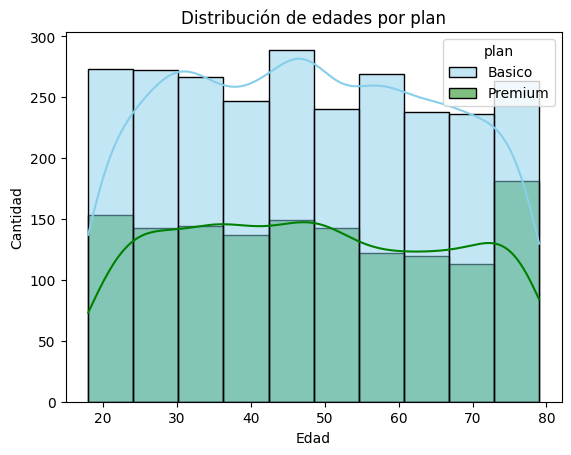

In [17]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", bins=10, kde=True, hue="plan", palette=["skyblue", "green"])
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.title("Distribución de edades por plan")
plt.show()

💡Insights: 
- Distribución uniforme, no parece haber una relación clara entre el tipo de plan y la edad, aunque se puede ver que hay mayor cantidad de usuarios con plan básico.

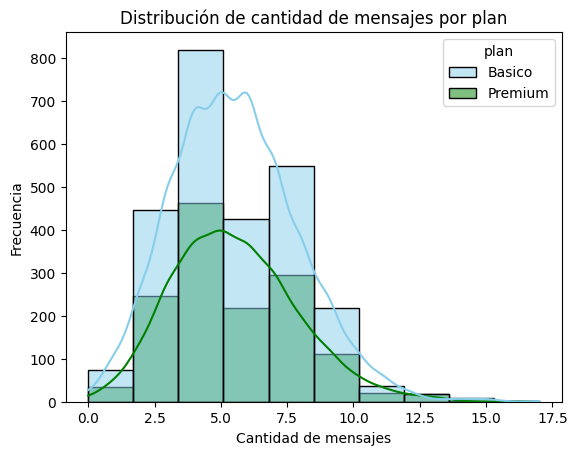

In [18]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=10, kde=True, palette=["skyblue", "green"])
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.title("Distribución de cantidad de mensajes por plan")
plt.show()



💡Insights: 
- Se puede observar un sesgo hacia la derecha por lo podemos deducir que la cantidad de mensajes enviados normalmente es baja, entre un 3 y 5 es donde se concentra el mayor npumero de cantidad de mensajes enviados. De igual manera no parece haber mucha relación entre el tipo de plan con la cantidad de mensajes enviados

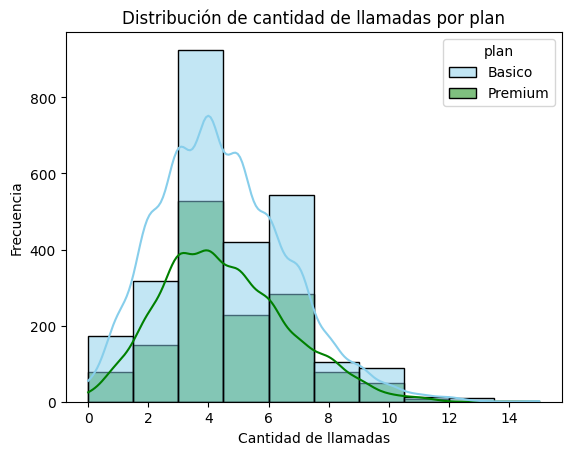

In [45]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=10, kde=True, palette=["skyblue", "green"])
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.title("Distribución de cantidad de llamadas por plan")
plt.show()


💡Insights: 
- Distribución sesgada a la derecha. Los usuarios generar mayormente un total de entre 3 y 5 llamadas. de igual manera no se ve mucha diferencia entre planes.

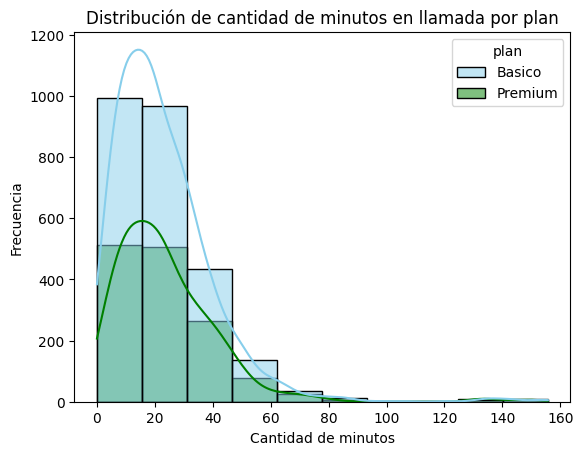

In [19]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=10, kde=True, palette=["skyblue", "green"])
plt.xlabel("Cantidad de minutos")
plt.ylabel("Frecuencia")
plt.title("Distribución de cantidad de minutos en llamada por plan")
plt.show()


💡Insights: 
- Distrubicón con sesgo hacia la derecha. Los usyarios suelen llamar entre 0 y 30 min por llamada. muy pocos usuarios llegan a llamar hasta 150 minutos o poco mas. No se encuentra relación en la cantidad de minutos por llamadas por plan

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

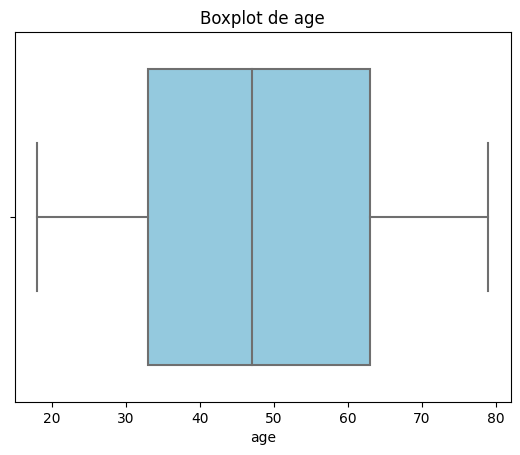

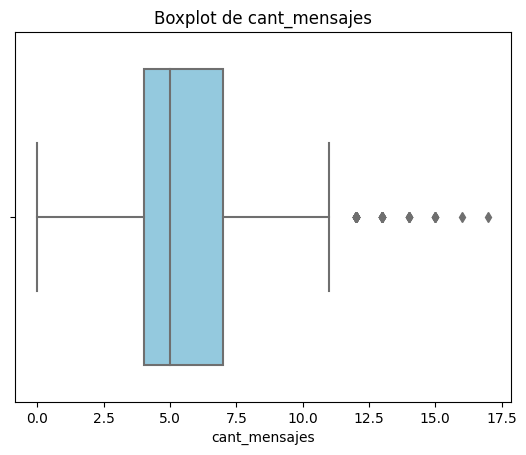

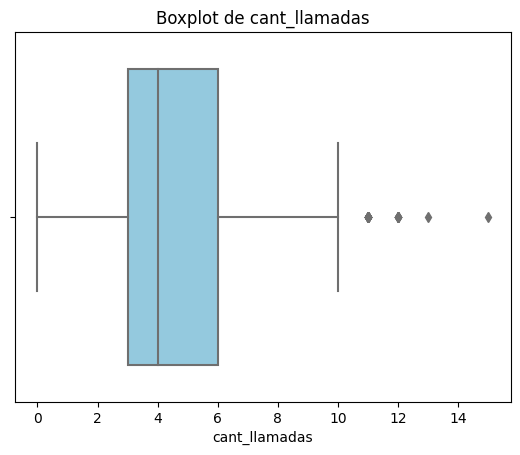

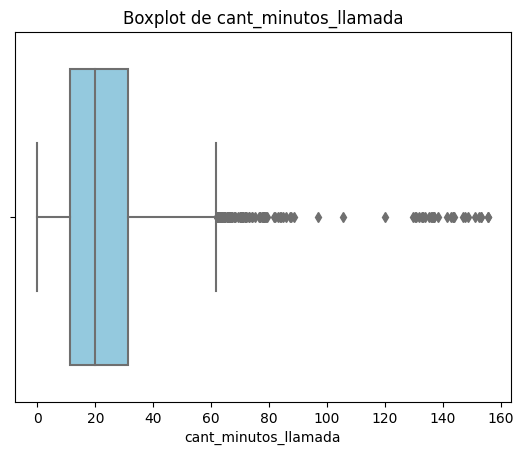

In [20]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(user_profile[col], color="skyblue")
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers hacia valores altos
- cant_llamadas: presenta outliers hacia valores altos
- cant_minutos_llamada: presenta outliers hacia valores altos

In [21]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]



In [22]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se mantienen los outliers ya que no son muy grandes y si suena realizta la cantidad de mensajes realizados
- cant_llamadas: Mantener, de igual manera, no es muy grande los outlies en comparación con el pico del boxplot y no es tan irreal el dato
- cant_minutos_llamada: Dependerá de lo que se quiera o como se quiera analizar, pero los outliers pueden ser realistas ya que puede haber gente que dure horas hablando con otras personas, o puede ser casos de por ejemplo call centers. en lo personal, yo los omitiría y dejaría ese análisis para otro caso de llamadas con duración alta

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [23]:
# Crear columna grupo_uso

#Crear función clasificar usuario

def clasificar_uso(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"
        
user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)


In [24]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [25]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row["age"] < 30:
        return "Joven"
    elif row["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)


In [26]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

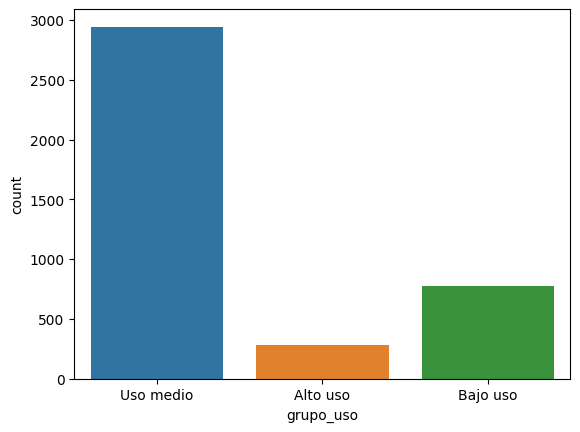

In [27]:
# Visualización de los segmentos por uso

sns.countplot(x="grupo_uso", data=user_profile)

plt.show()


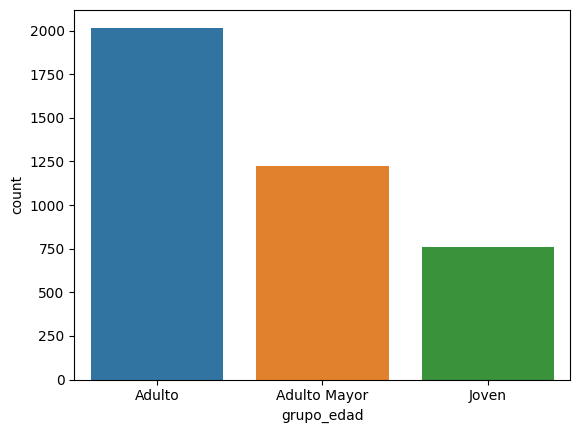

In [28]:
# Visualización de los segmentos por edad
sns.countplot(x="grupo_edad", data=user_profile)

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Para el dataset de `users`, se encontraron nulos en las columnas `city` y `churn_date`, siendo esta última, la columna con mayor cantidad de nulos con un valor de 3534.
- En cuestión porcentaje, `churn_date`equivale al 88.35% de nulos y `city` al 11.72%
- En `users` Se encontraron valores por encima de la fecha actual, siendo estas de mayo de 2026 y estamos a marzo de 2026 y se reemplazaron por NA
- También se encontró que la columna àge`tenía valores imposibles, siendo estos un valor de -999, los cuales se tuvieron que reemplazar por la mediana
- La columna `city`tenía valores inexistentes como `?`el cual se reemplazo por NA
- Para el data set de `usage`, se encontraron nulos en las columnas `date`, `duration`y `length`
- En cuestión de porcentaje, `date`equivale al 0.12%, `duratiom`al 55.19% y `length`al 44.74%
- Se entiende que los nulos en `duration`y `length`se deben a que para el tipo de uso `call`se mide en duración y el tipo de uso `text`se mide en longitud


🔍 **Segmentos por Edad**
- Se encontraron 3 segmentos por edad, `Adulto`, `Adulto mayor` y `Joven`
- De estos 3 grupos se encontró que predomina el grupo `Adulto` con un valor de aproximadamente 2000 registros y estando en un rango de edad de menos de 30 a 59 años
- El segmento `Adulto mayor` es el segundo grupo con mayor registros con un valor aproximado de 1250 registros y estando en un rango de edad de 60 a mas años
- El segmento `Joven` es el grupo con menor registros siendo de un aproximado de 750 y en un rango de edad de menores de 30 años


📊 **Segmentos por Nivel de Uso**
- Se encontraron 3 segmentos por uso, `Uso medio`, `Alto uso` y `Bajo uso`
- De estos 3 grupos se encontró que predomina el grupo `Uso medio`con un valor aproximado de poco menos de 3000 registros y estando en un rango de uso de 5 a 9 llamadas y 5 a 9 mensajes de texto
- El grupo `Alto uso` es el grupo con menor cantidad de registros con un valor aproximado de 250 registros y estando en un ranfo de uso de mas de 10 llamadas y mas de 10 mensajes de texto
- El grupo `Bajo uso` es el segundo grupo con mayor cantidad de registros de un aproximado de 1000 registros y estando en un rango de abajo de 5 llamadas y abajo de 5 mensajes de texto


➡️ Esto sugiere que el grupo que predomina en usar los servicios móviles son los adultos entre un rango de 30 y 59 años y con un uso medio, lo cual suena muy realista ya que los adultos son las personas que tienen el poder adquisitivo para contratar líneas telefónicas móviles y que mas lo utilizan , ya sea de manera personal o de trabajo, mientras que los adultos mayores, por lo mismo de ya pertenecer a otra generación casi no utilizan servicios móviles y hablando de los jovenes, normalmente ellos se comunican mas por redes sociales.


💡 **Recomendaciones**
- Recomendaría basar las estrategías del negocio enfocandose en el sector adulto, buscando promociones para adquirir líneas telefónicas y mejorando sus planes. Actualmente la mayoría de las líneas telefónicas, si no es que todas, ya cuentan con llamadas y mensajes ilimitados de manera local, por lo que se recomienda basar las ofertas o promociones para buscar que mas adultos adquieran mas líneas en lugar de buscar que utilicen mas el servicio
- Otra recomendación sería buscar la manera de atraer mas jovenes mediante mejores planes de internet ya que son el sector que mayormente utiliza el internet en dispositivos móviles, y teniendo mejores planes de internet o de redes sociales ilimitadas será la manera en poder artraer mas jovenes.
- Por último, recomendaría basar el análisis en el uso de internet y en que aplicaciones se utilizan, como dije anteriormente, actualmente la mayoría de los servicios de telefonía móvil ya incluyen minutos y mensajes ilimitados

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/EAndrade2121/connectatel-analysis